In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [5]:
nifty50 = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\raw\nifty50.csv")
nifty100 = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\raw\nifty100.csv")

In [7]:
nav = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\clean_nav.csv")

In [11]:
print(nifty50.columns)

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [13]:
nifty50.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
1,Date,NaN,NaN,NaN,NaN,NaN
2,2022-01-03,17625.69921875,17646.650390625,17383.30078125,17387.150390625,200500
3,2022-01-04,17805.25,17827.599609375,17593.55078125,17681.400390625,247400
4,2022-01-05,17925.25,17944.69921875,17748.849609375,17820.099609375,251500


In [15]:
nifty50 = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\raw\nifty50.csv")

In [17]:
nifty50.rename(columns={"Price": "Date"}, inplace=True)

In [23]:
nifty50 = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\raw\nifty50.csv")

print(nifty50.head(10))
print(nifty50.columns.tolist())

        Price            Close             High              Low  \
0      Ticker            ^NSEI            ^NSEI            ^NSEI   
1        Date              NaN              NaN              NaN   
2  2022-01-03   17625.69921875  17646.650390625   17383.30078125   
3  2022-01-04         17805.25  17827.599609375   17593.55078125   
4  2022-01-05         17925.25   17944.69921875  17748.849609375   
5  2022-01-06  17745.900390625   17797.94921875   17655.55078125   
6  2022-01-07   17812.69921875          17905.0   17704.55078125   
7  2022-01-10   18003.30078125   18017.44921875  17879.150390625   
8  2022-01-11         18055.75         18081.25  17964.400390625   
9  2022-01-12  18212.349609375   18227.94921875   18128.80078125   

              Open  Volume  
0            ^NSEI   ^NSEI  
1              NaN     NaN  
2  17387.150390625  200500  
3  17681.400390625  247400  
4  17820.099609375  251500  
5          17768.5  236500  
6  17797.599609375  239300  
7   17913.30078125 

In [25]:
# Remove the first two rows
nifty50 = nifty50.iloc[2:].reset_index(drop=True)

# Rename the first column
nifty50.rename(columns={"Price": "Date"}, inplace=True)

# Convert Date to datetime
nifty50["Date"] = pd.to_datetime(nifty50["Date"])

# Convert numeric columns
cols = ["Close", "High", "Low", "Open", "Volume"]
nifty50[cols] = nifty50[cols].apply(pd.to_numeric)

# Calculate daily return
nifty50["daily_return"] = nifty50["Close"].pct_change()

# Check the result
print(nifty50.head())

        Date         Close          High           Low          Open  Volume  \
0 2022-01-03  17625.699219  17646.650391  17383.300781  17387.150391  200500   
1 2022-01-04  17805.250000  17827.599609  17593.550781  17681.400391  247400   
2 2022-01-05  17925.250000  17944.699219  17748.849609  17820.099609  251500   
3 2022-01-06  17745.900391  17797.949219  17655.550781  17768.500000  236500   
4 2022-01-07  17812.699219  17905.000000  17704.550781  17797.599609  239300   

   daily_return  
0           NaN  
1      0.010187  
2      0.006740  
3     -0.010005  
4      0.003764  


In [27]:
# Remove the first two rows
nifty100 = nifty100.iloc[2:].reset_index(drop=True)

# Rename the first column
nifty100.rename(columns={"Price": "Date"}, inplace=True)

# Convert Date to datetime
nifty100["Date"] = pd.to_datetime(nifty100["Date"])

# Convert numeric columns
cols = ["Close", "High", "Low", "Open", "Volume"]
nifty100[cols] = nifty100[cols].apply(pd.to_numeric)

# Calculate daily return
nifty100["daily_return"] = nifty100["Close"].pct_change()

# Check the result
print(nifty100.head())

        Date         Close          High           Low          Open   Volume  \
0 2022-01-03  17874.000000  17894.150391  17651.449219  17654.449219  5756800   
1 2022-01-04  18030.949219  18051.500000  17831.500000  17934.500000  6744900   
2 2022-01-05  18147.500000  18164.699219  17974.900391  18044.300781  7898200   
3 2022-01-06  17985.599609  18025.250000  17889.750000  17997.599609  5508600   
4 2022-01-07  18053.949219  18140.849609  17944.400391  18035.699219  5914700   

   daily_return  
0           NaN  
1      0.008781  
2      0.006464  
3     -0.008921  
4      0.003800  


In [29]:
print(nifty50.info())
print(nifty100.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1086 entries, 0 to 1085
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1086 non-null   datetime64[ns]
 1   Close         1086 non-null   float64       
 2   High          1086 non-null   float64       
 3   Low           1086 non-null   float64       
 4   Open          1086 non-null   float64       
 5   Volume        1086 non-null   int64         
 6   daily_return  1085 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 59.5 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1080 non-null   datetime64[ns]
 1   Close         1080 non-null   float64       
 2   High          1080 non-null   float64       
 3   Low     

In [31]:
from pathlib import Path

processed = Path(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed")

for file in processed.iterdir():
    print(file.name)

clean_nav.csv
clean_performance.csv
clean_transactions.csv


In [33]:
from pathlib import Path

raw = Path(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\raw")

for file in raw.iterdir():
    print(file.name)

01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv
Axis_Bluechip_nav.csv
hdfc_top100_live_nav.csv
ICICI_Bluechip_nav.csv
Kotak_Bluechip_nav.csv
nifty100.csv
nifty50.csv
Nippon_LargeCap_nav.csv
SBI_Bluechip_nav.csv


In [19]:
print(nifty50.head())
print(nifty50.columns)

         Date           Close             High              Low  \
0      Ticker           ^NSEI            ^NSEI            ^NSEI   
1        Date             NaN              NaN              NaN   
2  2022-01-03  17625.69921875  17646.650390625   17383.30078125   
3  2022-01-04        17805.25  17827.599609375   17593.55078125   
4  2022-01-05        17925.25   17944.69921875  17748.849609375   

              Open  Volume  
0            ^NSEI   ^NSEI  
1              NaN     NaN  
2  17387.150390625  200500  
3  17681.400390625  247400  
4  17820.099609375  251500  
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [37]:
nav = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\clean_nav.csv")

print(nav.head())
print(nav.columns.tolist())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
['amfi_code', 'date', 'nav']


In [39]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort the data
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily return for each fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Check the result
print(nav.head(10))

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


In [43]:
nav.to_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\returns_computed.csv", index=False)

In [45]:
import pandas as pd
import numpy as np

def calculate_cagr(group):
    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (group.iloc[-1]["date"] - group.iloc[0]["date"]).days / 365.25

    if years <= 0:
        return np.nan

    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

cagr = nav.groupby("amfi_code").apply(calculate_cagr).reset_index()
cagr.columns = ["amfi_code", "CAGR (%)"]

print(cagr)

    amfi_code   CAGR (%)
0      100016   2.637074
1      100025   4.458210
2      100033  30.123153
3      101206  23.538361
4      101207   7.938765
5      101208   6.509027
6      102885  18.232379
7      102886   1.171745
8      102887  16.841120
9      118632  24.049493
10     118633  16.274217
11     118634  16.373474
12     118635  15.957231
13     118636   5.316890
14     119092   6.367989
15     119093   7.897558
16     119094  28.214417
17     119095   1.521505
18     119120   5.889419
19     119551  25.804686
20     119552  21.524236
21     119598  32.423536
22     119599   2.054485
23     120503  18.785326
24     120504  23.295119
25     120505  32.827406
26     120506  17.084867
27     120507   7.237540
28     120841  13.532211
29     120842   6.701543
30     120843  30.907455
31     120844   6.915273
32     125497  19.017795
33     125498  11.301817
34     148567  30.974108
35     148568  22.516869
36     148569  27.595888


C:\Users\chand\AppData\Local\Temp\ipykernel_19656\1001197171.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cagr = nav.groupby("amfi_code").apply(calculate_cagr).reset_index()


In [47]:
cagr.to_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\cagr_report.csv", index=False)

In [49]:
import numpy as np

# Annual risk-free rate (6.5%)
risk_free_rate = 0.065

def calculate_sharpe(group):
    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        return np.nan

    excess_returns = returns - (risk_free_rate / 252)

    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)

    return sharpe

sharpe = nav.groupby("amfi_code").apply(calculate_sharpe).reset_index()
sharpe.columns = ["amfi_code", "Sharpe Ratio"]

print(sharpe)

    amfi_code  Sharpe Ratio
0      100016     -0.201517
1      100025     -0.567095
2      100033      1.093699
3      101206      1.027213
4      101207      0.162661
5      101208     -0.815567
6      102885      0.817099
7      102886     -0.205832
8      102887      0.619518
9      118632      1.081659
10     118633      0.645207
11     118634      0.448434
12     118635      0.664857
13     118636     -0.356630
14     119092      0.030785
15     119093      0.129614
16     119094      0.998231
17     119095     -0.075974
18     119120     -0.226575
19     119551      1.208267
20     119552      0.953279
21     119598      0.945308
22     119599     -0.057187
23     120503      0.797973
24     120504      1.026524
25     120505      1.180101
26     120506      0.648879
27     120507      0.495723
28     120841      0.494273
29     120842      0.076000
30     120843      1.306744
31     120844     -0.088747
32     125497      0.775790
33     125498      0.300612
34     148567      1

C:\Users\chand\AppData\Local\Temp\ipykernel_19656\3893286461.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sharpe = nav.groupby("amfi_code").apply(calculate_sharpe).reset_index()


In [51]:
import numpy as np

risk_free_rate = 0.065

def calculate_sortino(group):
    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        return np.nan

    excess_returns = returns - (risk_free_rate / 252)

    downside_returns = excess_returns[excess_returns < 0]

    if len(downside_returns) == 0:
        return np.nan

    downside_std = downside_returns.std()

    if downside_std == 0:
        return np.nan

    sortino = (excess_returns.mean() / downside_std) * np.sqrt(252)

    return sortino

sortino = nav.groupby("amfi_code").apply(calculate_sortino).reset_index()
sortino.columns = ["amfi_code", "Sortino Ratio"]

print(sortino)

    amfi_code  Sortino Ratio
0      100016      -0.348196
1      100025      -0.915371
2      100033       1.823824
3      101206       1.785592
4      101207       0.274615
5      101208      -1.324583
6      102885       1.418194
7      102886      -0.344973
8      102887       1.079016
9      118632       1.839859
10     118633       1.140144
11     118634       0.744123
12     118635       1.130602
13     118636      -0.599017
14     119092       0.051908
15     119093       0.219528
16     119094       1.698390
17     119095      -0.127050
18     119120      -0.366523
19     119551       2.103952
20     119552       1.603981
21     119598       1.661245
22     119599      -0.094080
23     120503       1.329023
24     120504       1.785043
25     120505       2.010035
26     120506       1.088341
27     120507       0.827574
28     120841       0.854822
29     120842       0.123519
30     120843       2.352942
31     120844      -0.147815
32     125497       1.311160
33     125498 

C:\Users\chand\AppData\Local\Temp\ipykernel_19656\1837457896.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sortino = nav.groupby("amfi_code").apply(calculate_sortino).reset_index()


In [55]:
sortino.to_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\sortino_ratio.csv", index=False)

In [57]:
sharpe.to_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\sharpe_ratio.csv", index=False)

In [59]:
import pandas as pd
import numpy as np

# Prepare benchmark (Nifty 50)
benchmark = nifty50[["Date", "daily_return"]].copy()
benchmark.columns = ["date", "benchmark_return"]

# Merge benchmark returns with fund returns
merged = pd.merge(nav, benchmark, on="date", how="inner")

results = []

for fund, group in merged.groupby("amfi_code"):
    group = group.dropna(subset=["daily_return", "benchmark_return"])

    if len(group) < 2:
        continue

    beta = np.cov(group["daily_return"], group["benchmark_return"])[0, 1] / np.var(group["benchmark_return"])

    alpha = (
        group["daily_return"].mean()
        - beta * group["benchmark_return"].mean()
    ) * 252

    results.append([fund, alpha, beta])

alpha_beta = pd.DataFrame(results, columns=["amfi_code", "Alpha", "Beta"])

print(alpha_beta.head())

   amfi_code     Alpha      Beta
0     100016  0.043439  0.039109
1     100025  0.045444 -0.008652
2     100033  0.255114  0.005311
3     101206  0.203109  0.027073
4     101207  0.069089  0.071078


In [61]:
alpha_beta.to_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\alpha_beta.csv", index=False)

In [63]:
import pandas as pd
import numpy as np

def calculate_max_drawdown(group):
    group = group.sort_values("date")

    running_max = group["nav"].cummax()
    drawdown = (group["nav"] - running_max) / running_max

    return drawdown.min() * 100

max_drawdown = nav.groupby("amfi_code").apply(calculate_max_drawdown).reset_index()
max_drawdown.columns = ["amfi_code", "Max Drawdown (%)"]

print(max_drawdown)

    amfi_code  Max Drawdown (%)
0      100016        -24.734441
1      100025         -4.308264
2      100033        -16.217209
3      101206        -11.291596
4      101207        -35.446916
5      101208         -0.162250
6      102885        -10.859862
7      102886        -28.001124
8      102887        -21.539827
9      118632        -17.414075
10     118633        -18.629743
11     118634        -23.344886
12     118635        -11.650625
13     118636         -8.316362
14     119092        -14.401618
15     119093        -21.751396
16     119094        -20.960884
17     119095        -51.677754
18     119120         -4.328729
19     119551        -15.012385
20     119552        -11.803494
21     119598        -28.706006
22     119599        -52.574221
23     120503        -13.897863
24     120504        -12.588276
25     120505        -18.188514
26     120506        -19.825658
27     120507         -0.097731
28     120841        -17.573614
29     120842        -24.003511
30     1

C:\Users\chand\AppData\Local\Temp\ipykernel_19656\580680108.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  max_drawdown = nav.groupby("amfi_code").apply(calculate_max_drawdown).reset_index()


In [65]:
max_drawdown.to_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\max_drawdown.csv", index=False)

In [67]:
performance_metrics = cagr.merge(sharpe, on="amfi_code")
performance_metrics = performance_metrics.merge(sortino, on="amfi_code")
performance_metrics = performance_metrics.merge(alpha_beta, on="amfi_code")
performance_metrics = performance_metrics.merge(max_drawdown, on="amfi_code")

print(performance_metrics.head())

   amfi_code   CAGR (%)  Sharpe Ratio  Sortino Ratio     Alpha      Beta  \
0     100016   2.637074     -0.201517      -0.348196  0.043439  0.039109   
1     100025   4.458210     -0.567095      -0.915371  0.045444 -0.008652   
2     100033  30.123153      1.093699       1.823824  0.255114  0.005311   
3     101206  23.538361      1.027213       1.785592  0.203109  0.027073   
4     101207   7.938765      0.162661       0.274615  0.069089  0.071078   

   Max Drawdown (%)  
0        -24.734441  
1         -4.308264  
2        -16.217209  
3        -11.291596  
4        -35.446916  


In [69]:
performance_metrics.to_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\performance_metrics.csv", index=False)

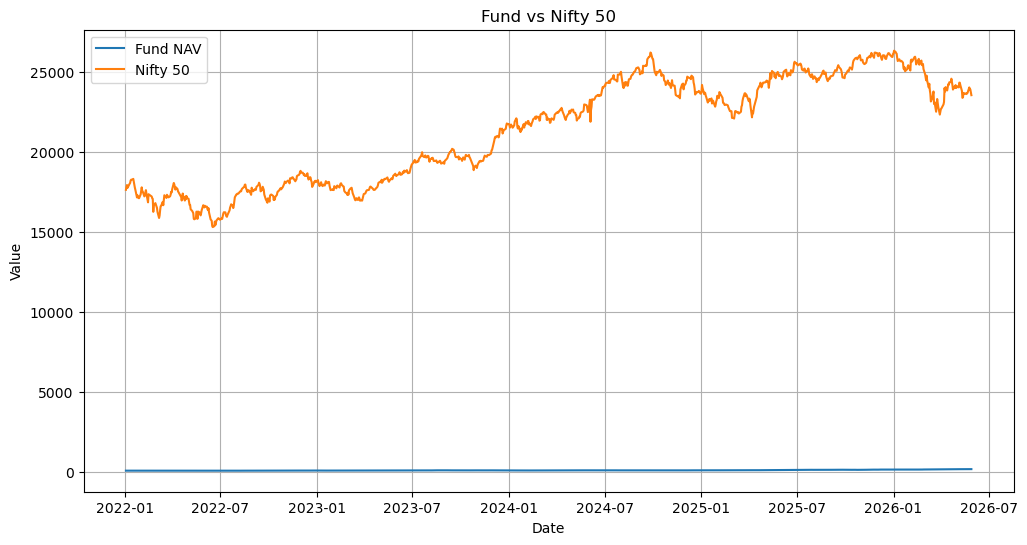

In [71]:
import matplotlib.pyplot as plt

fund = nav[nav["amfi_code"] == 119551]

plt.figure(figsize=(12,6))
plt.plot(fund["date"], fund["nav"], label="Fund NAV")
plt.plot(nifty50["Date"], nifty50["Close"], label="Nifty 50")

plt.title("Fund vs Nifty 50")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

In [73]:
plt.savefig(r"C:\Users\chand\Downloads\mutual_fund_analytics\reports\benchmark_chart.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [77]:
import os

print(os.listdir(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed"))

['alpha_beta.csv', 'cagr_report.csv', 'clean_nav.csv', 'clean_performance.csv', 'clean_transactions.csv', 'max_drawdown.csv', 'performance_metrics.csv', 'returns_computed.csv', 'sharpe_ratio.csv', 'sortino_ratio.csv']


In [79]:
performance_metrics.head()

,amfi_code,CAGR (%),Sharpe Ratio,Sortino Ratio,Alpha,Beta,Max Drawdown (%)
0,100016,2.637074,-0.201517,-0.348196,0.043439,0.039109,-24.734441
1,100025,4.458210,-0.567095,-0.915371,0.045444,-0.008652,-4.308264
2,100033,30.123153,1.093699,1.823824,0.255114,0.005311,-16.217209
3,101206,23.538361,1.027213,1.785592,0.203109,0.027073,-11.291596
4,101207,7.938765,0.162661,0.274615,0.069089,0.071078,-35.446916


In [81]:
performance_metrics.isnull().sum()

amfi_code           0
CAGR (%)            0
Sharpe Ratio        0
Sortino Ratio       0
Alpha               0
Beta                0
Max Drawdown (%)    0
dtype: int64

In [83]:
plt.show()